In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
# Load the original count and generated count files into separate DataFrames
df_original = pd.read_excel('/content/drive/MyDrive/Results_lettuce csv/Leaf Count _Original M2.xlsx')
df_generated = pd.read_excel('/content/drive/MyDrive/Results_lettuce csv/Leaf_count_method2_corrected.xlsx')

In [ ]:
# Check column names of the original count file
original_columns = df_original.columns
print("Original Count File Columns:", original_columns)

# Check column names of the generated count file
generated_columns = df_generated.columns
print("Generated Count File Columns:", generated_columns)

Original Count File Columns: Index(['Plant Name', 'Date_Month_Year', 'Time', 'Leaf_Count'], dtype='object')
Generated Count File Columns: Index(['Plant Name', 'Date_Month_Year', 'Time', 'Leaf_Count'], dtype='object')


In [ ]:
df_original.shape, df_generated.shape

((360, 4), (360, 4))

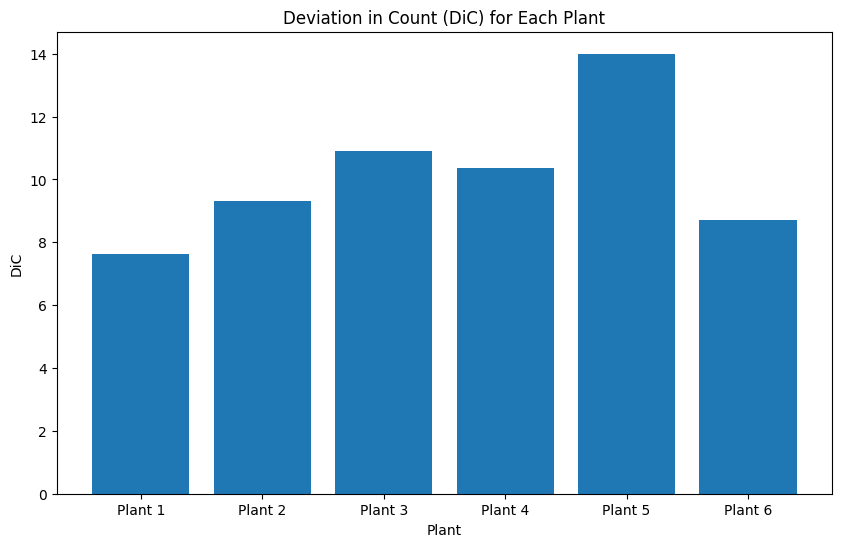

In [ ]:
# Merge the original and generated DataFrames based on common columns
merged_df = df_original.merge(df_generated, on=['Plant Name', 'Date_Month_Year', 'Time'])

# Compute the DiC for each plant
plants = ['Plant 1', 'Plant 2', 'Plant 3', 'Plant 4', 'Plant 5', 'Plant 6']
dic_values = []

for plant in plants:
    # Filter the merged DataFrame for the current plant
    filtered_df = merged_df[merged_df['Plant Name'] == plant]

    # Extract the original count and generated count for the current plant
    original_count = filtered_df['Leaf_Count_x'].values
    generated_count = filtered_df['Leaf_Count_y'].values

    # Compute the DiC for the current plant
       # Compute the DiC for the current plant
    dic = np.abs(generated_count - original_count)

    # Append the DiC values for the current plant
    dic_values.append(dic.mean())  # Extend the list instead of appending ndarray

# Create a bar plot for the DiC values+
plt.figure(figsize=(10, 6))
plt.bar(plants, dic_values)
plt.xlabel('Plant')
plt.ylabel('DiC')
plt.title('Deviation in Count (DiC) for Each Plant')
plt.show()

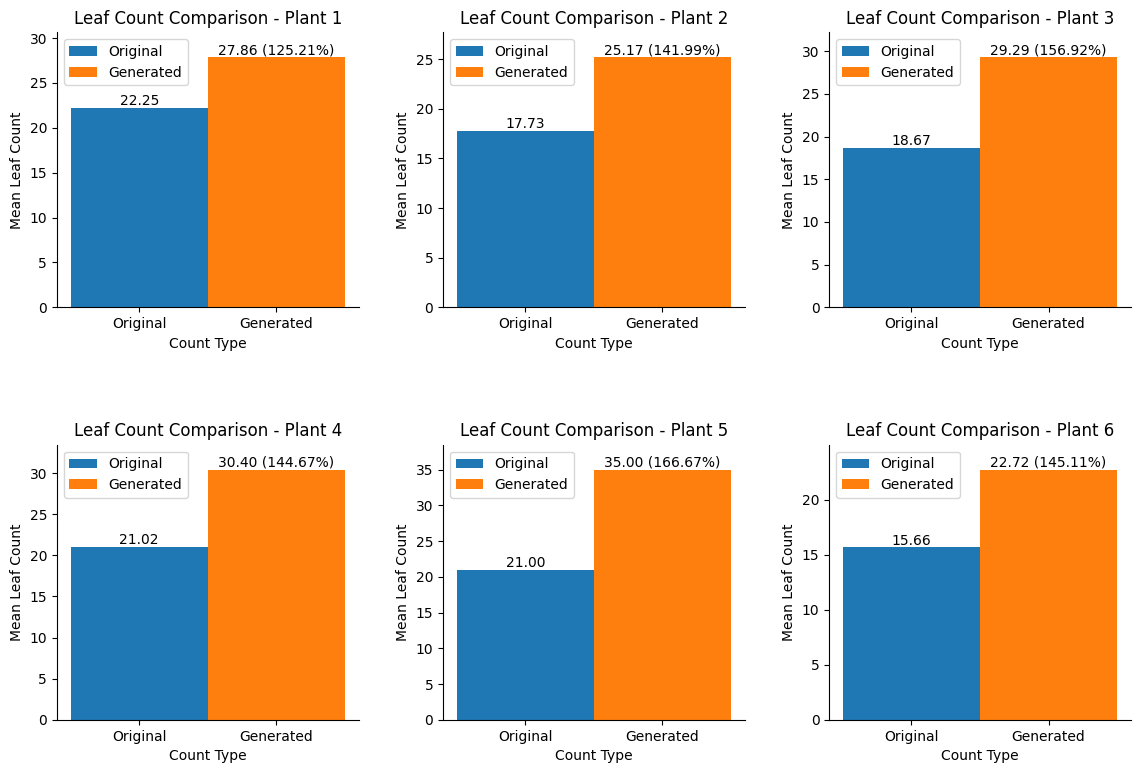

In [ ]:
# Select the plants
plants = ['Plant 1', 'Plant 2', 'Plant 3', 'Plant 4', 'Plant 5', 'Plant 6']

# Calculate the number of rows and columns for the grid layout
num_rows = 2
num_cols = 3

# Create a grid of subplots for each plant
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 8))
fig.tight_layout(pad=3.0)

# Define the width of the bars
bar_width = 0.4

# Iterate over the plants and plot in the grid
for i, plant in enumerate(plants):
    # Compute the row and column index for the current plant
    row_idx = i // num_cols
    col_idx = i % num_cols

    # Filter the merged DataFrame for the current plant
    filtered_df = merged_df[merged_df['Plant Name'] == plant]

    # Extract the leaf count for the original and generated count
    original_count = filtered_df['Leaf_Count_x']
    generated_count = filtered_df['Leaf_Count_y']

    # Compute the mean leaf count for original and generated count
    mean_original_count = np.mean(original_count)
    mean_generated_count = np.mean(generated_count)

    # Calculate the percentage of correctness
    percentage_correct = (mean_generated_count / mean_original_count) * 100

    # Plot the bar chart in the current subplot
    ax = axes[row_idx, col_idx]
    ax.bar([0], [mean_original_count], width=bar_width, label='Original')
    ax.bar([bar_width], [mean_generated_count], width=bar_width, label='Generated')
    ax.set_xticks([0, bar_width])
    ax.set_xticklabels(['Original', 'Generated'])
    ax.set_xlabel('Count Type')
    ax.set_ylabel('Mean Leaf Count')
    ax.set_title(f'Leaf Count Comparison - {plant}')
    ax.text(0, mean_original_count, f'{mean_original_count:.2f}', ha='center', va='bottom')
    ax.text(bar_width, mean_generated_count, f'{mean_generated_count:.2f} ({percentage_correct:.2f}%)', ha='center', va='bottom')
    ax.set_ylim(0, max(mean_original_count, mean_generated_count) * 1.1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend()

# Hide any empty subplots
if len(plants) < num_rows * num_cols:
    for i in range(len(plants), num_rows * num_cols):
        row_idx = i // num_cols
        col_idx = i % num_cols
        axes[row_idx, col_idx].axis('off')

# Adjust the spacing between subplots
plt.subplots_adjust(hspace=0.5)

# Show the plot
plt.show()

In [ ]:
# List of plants
plants = ['Plant 1', 'Plant 2', 'Plant 3', 'Plant 4', 'Plant 5', 'Plant 6']

# Compute the difference in count for each plant
for plant in plants:
    # Filter the original dataframe for the current plant
    original_plant_df = df_original[df_original['Plant Name'] == plant]

    # Filter the generated dataframe for the current plant
    generated_plant_df = df_generated[df_generated['Plant Name'] == plant]

    # Merge the dataframes based on common columns
    merged_df = original_plant_df.merge(generated_plant_df, on=['Date_Month_Year', 'Time'], suffixes=('_original', '_generated'))

    # Compute the difference in count
    merged_df['Count_Difference'] = merged_df['Leaf_Count_generated'] - merged_df['Leaf_Count_original']

    # Print the plant-specific merged dataframe with the count difference
    print(f"Plant: {plant}")
    print(merged_df)
    print('\n')

Plant: Plant 1
   Plant Name_original Date_Month_Year  Time  Leaf_Count_original  \
0              Plant 1      30_05_2023     7                   14   
1              Plant 1      30_05_2023     9                   14   
2              Plant 1      30_05_2023    11                   14   
3              Plant 1      30_05_2023    13                   14   
4              Plant 1      30_05_2023    15                   14   
..                 ...             ...   ...                  ...   
59             Plant 1      06_06_2023    13                   30   
60             Plant 1      06_06_2023    15                   30   
61             Plant 1      06_06_2023    17                   30   
62             Plant 1      06_06_2023    19                   30   
63             Plant 1      06_06_2023    21                   30   

   Plant Name_generated  Leaf_Count_generated  Count_Difference  
0               Plant 1                     9                -5  
1               Plant 1 

In [ ]:
# Merge the dataframes based on common columns using an outer join
merged_df = df_original.merge(df_generated, on=['Plant Name', 'Date_Month_Year', 'Time'], how='outer', suffixes=('_original', '_generated'))

# Compute the absolute difference in count
merged_df['Count_Difference_Absolute'] = abs(merged_df['Leaf_Count_generated'] - merged_df['Leaf_Count_original'])

# Save the absolute difference in count values as a CSV file
merged_df[['Plant Name', 'Date_Month_Year', 'Time', 'Count_Difference_Absolute']].to_csv('absolute_difference.csv', index=False)